In [1]:
import numpy as np
import matplotlib.pyplot as plt

Run h=0.01: (Reference Run set)
Run h=0.06: Total Accumulated Error = 0.3173
Run h=0.11: Total Accumulated Error = 0.3988
Run h=0.16: Total Accumulated Error = 0.3498
Run h=0.21: Total Accumulated Error = 0.5982
Run h=0.26: Total Accumulated Error = 0.5746
Run h=0.31: Total Accumulated Error = 0.4113
Run h=0.36: Total Accumulated Error = 0.6337
Run h=0.41: Total Accumulated Error = 0.5705
Run h=0.46: Total Accumulated Error = 0.4757
Run h=0.51: Total Accumulated Error = 0.5823
Run h=0.56: Total Accumulated Error = 0.6698
Run h=0.61: Total Accumulated Error = 0.5275
Run h=0.66: Total Accumulated Error = 0.6652
Run h=0.71: Total Accumulated Error = 0.8805
Run h=0.76: Total Accumulated Error = 1.1410
Run h=0.81: Total Accumulated Error = 1.1194
Run h=0.86: Total Accumulated Error = 1.3534
Run h=0.91: Total Accumulated Error = 1.6074
Run h=0.96: Total Accumulated Error = 1.8814


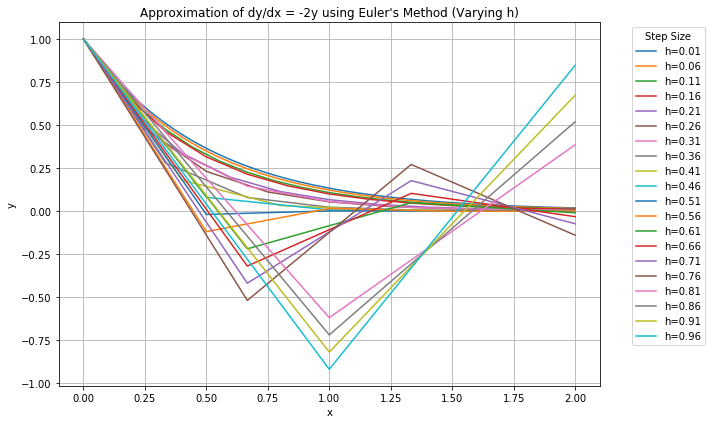

In [14]:

# Parameters from original code
x_start, x_end = 0, 2
y_initial = 1

def f(x, y):
    return -2 * y

#Loop step size from .01 to 1, steps of .05
step_sizes = np.arange(0.01, 1.01, 0.05)

# Variables to store the first run (h=0.01) as the reference "truth"
first_run_x = None
first_run_y = None

plt.figure(figsize=(10, 6))

for h in step_sizes:
    # Set up the run
    num_steps = int(np.round((x_end - x_start) / h))
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = y_initial

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Plot the current run
    plt.plot(x_values, y_values, label=f'h={h:.2f}')

    # Error Logic: current run vs first run
    if first_run_x is None:
        first_run_x, first_run_y = x_values, y_values
        print(f"Run h={h:.2f}: (Reference Run set)")
    else:
        # Match points between runs using interpolation for point-wise error
        y_ref = np.interp(x_values, first_run_x, first_run_y)
        errors = np.abs(y_values - y_ref)
        total_error = np.sum(errors)
        
        print(f"Run h={h:.2f}: Total Accumulated Error = {total_error:.4f}") #asked chat gpt how to print each value properly 
        # To see every point error: print(errors)

# Formatting the Plot
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method (Varying h)")
plt.legend(title="Step Size", bbox_to_anchor=(1.05, 1), loc='upper left') #asked chatgpt how to implement more advanced features into my plot
plt.grid(True)
plt.tight_layout() #reccommended by chat gpt
plt.show()